In [2]:
import pandas as pd

df = pd.read_csv('../data/customer_transactions.csv')

df.head()

,InvoiceID,CustomerID,InvoiceDate,ProductCategory,Quantity,UnitPrice,Discount,TotalAmount,Country,PaymentMethod
0,INV0021743,C00001,2026-03-02,Sports,1,1916.87,0.154,1621.94,India,UPI
1,INV0011210,C00001,2026-03-30,Beauty,3,682.92,0.180,1679.70,India,Cash on Delivery
2,INV0005218,C00001,2026-06-01,Beauty,3,2404.31,0.004,7187.33,UK,Credit Card
3,INV0013984,C00001,2026-06-20,Sports,3,2018.08,0.188,4913.53,India,UPI
4,INV0014055,C00001,2026-06-24,Grocery,2,713.38,0.024,1392.83,India,Cash on Delivery


In [3]:
print(df.shape)

(25075, 10)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 25075 entries, 0 to 25074
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   InvoiceID        25075 non-null  str    
 1   CustomerID       25075 non-null  str    
 2   InvoiceDate      25075 non-null  str    
 3   ProductCategory  25075 non-null  str    
 4   Quantity         25075 non-null  int64  
 5   UnitPrice        25075 non-null  float64
 6   Discount         25075 non-null  float64
 7   TotalAmount      25075 non-null  float64
 8   Country          24925 non-null  str    
 9   PaymentMethod    24975 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 1.9 MB
None


In [5]:
print(df.isnull().sum())
print("\n")
print(df.duplicated().sum())

InvoiceID            0
CustomerID           0
InvoiceDate          0
ProductCategory      0
Quantity             0
UnitPrice            0
Discount             0
TotalAmount          0
Country            150
PaymentMethod      100
dtype: int64


75


In [6]:
print(df.describe())

           Quantity     UnitPrice      Discount    TotalAmount
count  25075.000000  25075.000000  25075.000000   25075.000000
mean       3.685743   1832.179296      0.111380    6058.532790
std        1.809964   2439.680961      0.071485    9671.336198
min        1.000000     30.000000      0.000000      33.580000
25%        2.000000    485.260000      0.050000    1277.920000
50%        3.000000   1056.250000      0.102000    3023.100000
75%        5.000000   2191.445000      0.171000    6904.030000
max       14.000000  45000.000000      0.250000  223758.750000


In [7]:
#Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


#Handle missing values
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])

df["PaymentMethod"] = df["PaymentMethod"].fillna(
    df["PaymentMethod"].mode()[0]
)


#Remove duplicate rows
df = df.drop_duplicates()


#Check again
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

(25000, 10)

Missing Values:
InvoiceID          0
CustomerID         0
InvoiceDate        0
ProductCategory    0
Quantity           0
UnitPrice          0
Discount           0
TotalAmount        0
Country            0
PaymentMethod      0
dtype: int64

Duplicate Rows:
0

Data Types:
InvoiceID                     str
CustomerID                    str
InvoiceDate        datetime64[us]
ProductCategory               str
Quantity                    int64
UnitPrice                 float64
Discount                  float64
TotalAmount               float64
Country                       str
PaymentMethod                 str
dtype: object


In [8]:
print("Unique Customers:", df["CustomerID"].nunique())

Unique Customers: 2394


In [9]:
print("Unique Customers transactions:", df["CustomerID"].value_counts())

Unique Customers transactions: CustomerID
C00723    37
C00395    34
C00812    34
C01261    34
C01309    34
          ..
C02381     1
C02436     1
C02467     1
C02485     1
C02495     1
Name: count, Length: 2394, dtype: int64


In [10]:
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2025-04-01 00:00:00
End Date: 2026-09-14 00:00:00


In [11]:
print(df["ProductCategory"].value_counts())

ProductCategory
Grocery           4476
Fashion           3986
Home & Kitchen    3780
Electronics       3706
Accessories       2560
Beauty            2528
Sports            1993
Books             1971
Name: count, dtype: int64


In [12]:
print(df["Country"].value_counts())

Country
India        19565
UAE           1764
Nepal         1477
Singapore     1202
UK             992
Name: count, dtype: int64


In [13]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
UPI                 9994
Credit Card         6373
Debit Card          3941
Net Banking         3025
Cash on Delivery    1667
Name: count, dtype: int64


In [14]:
print("Total Revenue:", df["TotalAmount"].sum())
print("Average Transaction:", df["TotalAmount"].mean())
print("Median Transaction:", df["TotalAmount"].median())

Total Revenue: 151420713.02
Average Transaction: 6056.828520800001
Median Transaction: 3021.25


In [15]:
customer_spending = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

print(customer_spending.head(10))

CustomerID
C00287    405348.69
C02350    404372.75
C00395    397271.85
C00683    393868.99
C01236    371559.71
C02379    350235.65
C01743    344507.25
C02152    343411.52
C00364    341636.03
C00812    335263.30
Name: TotalAmount, dtype: float64


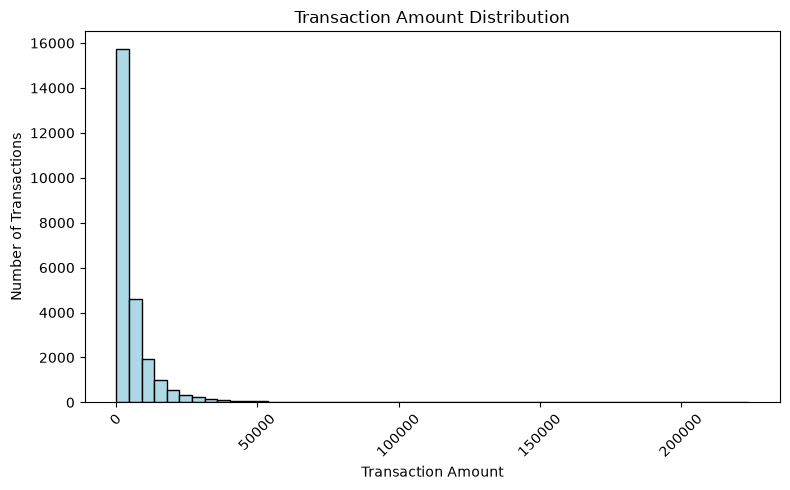

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["TotalAmount"], bins=50, color='lightblue', edgecolor='black')

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

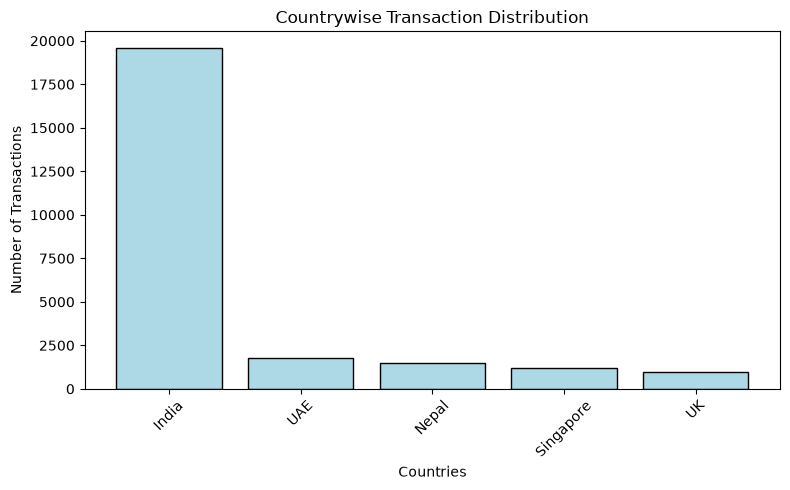

In [17]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(country_counts.index, country_counts.values,
    color="lightblue", edgecolor="black")

plt.xlabel("Countries")
plt.ylabel("Number of Transactions")
plt.title("Countrywise Transaction Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
df.columns

Index(['InvoiceID', 'CustomerID', 'InvoiceDate', 'ProductCategory', 'Quantity',
       'UnitPrice', 'Discount', 'TotalAmount', 'Country', 'PaymentMethod'],
      dtype='str')

In [19]:
print(df["InvoiceDate"].max())

2026-09-14 00:00:00


In [20]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1) # Set the reference date to one day after the latest invoice date

recency = (
    df.groupby("CustomerID")["InvoiceDate"] # Group by CustomerID and get the maximum InvoiceDate
      .max()                                # Get the maximum InvoiceDate for each customer
      .reset_index()                        # Reset the index to have CustomerID as a column
)

recency["Recency"] = (
    reference_date - recency["InvoiceDate"] # Calculate the difference between the reference date and the last purchase date
).dt.days                                   # Get the number of days

print(recency.head())

  CustomerID InvoiceDate  Recency
0     C00001  2026-06-24       83
1     C00002  2026-09-02       13
2     C00004  2026-08-12       34
3     C00005  2026-09-13        2
4     C00006  2025-11-10      309


In [21]:
frequency = (
    df.groupby("CustomerID")["InvoiceID"] # Group by CustomerID and count the number of unique InvoiceIDs
      .count()                            # Count the number of unique InvoiceIDs for each customer
      .reset_index()                      # Reset the index to have CustomerID as a column
)

frequency.rename(
    columns={"InvoiceID": "Frequency"},  # Rename the InvoiceID column to Frequency
    inplace=True                         # Modify the DataFrame in place
)

print(frequency.head())

  CustomerID  Frequency
0     C00001          5
1     C00002         24
2     C00004          4
3     C00005         18
4     C00006          2


In [ ]:
monetary = (
    df.groupby("CustomerID")["TotalAmount"] #Group by CustomerID and sum the TotalAmount for each customer
      .sum()
      .reset_index()
)

monetary.rename(
    columns={"TotalAmount": "Monetary"},    # Rename the TotalAmount column to Monetary
    inplace=True
)

print(monetary.head())

  CustomerID   Monetary
0     C00001   16795.33
1     C00002  167127.66
2     C00004   11675.59
3     C00005  135707.85
4     C00006   20151.03


In [23]:
rfm = recency[["CustomerID", "Recency"]].merge(
    frequency,
    on="CustomerID"
).merge(
    monetary,
    on="CustomerID"
)

print(rfm.head())

  CustomerID  Recency  Frequency   Monetary
0     C00001       83          5   16795.33
1     C00002       13         24  167127.66
2     C00004       34          4   11675.59
3     C00005        2         18  135707.85
4     C00006      309          2   20151.03


In [24]:
print(rfm.shape)

(2394, 4)


In [25]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  2394.000000  2394.000000    2394.000000
mean     51.843358    10.442774   63250.088981
std      80.461260     6.631317   60775.972496
min       1.000000     1.000000     159.040000
25%      12.000000     5.000000   18568.060000
50%      23.000000     9.000000   45576.655000
75%      47.000000    14.000000   89349.847500
max     497.000000    37.000000  405348.690000


In [27]:
print(rfm.isnull().sum())

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


In [28]:
X = rfm[["Recency", "Frequency", "Monetary"]]

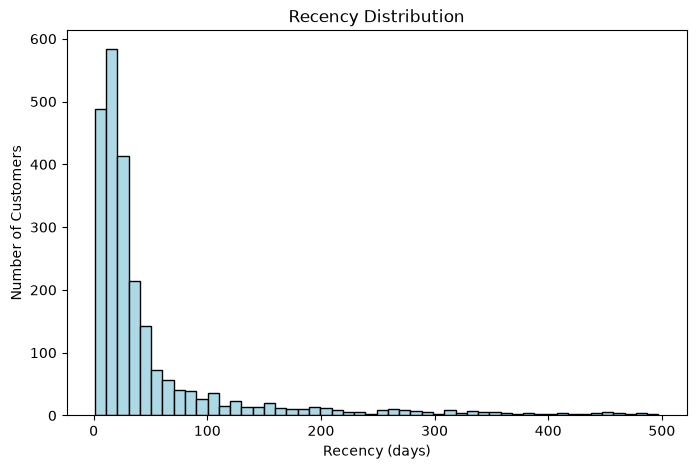

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 5))
hist = plt.hist(X["Recency"], bins=50, color='lightblue', edgecolor='black')
xlabel = plt.xlabel("Recency (days)")
ylabel = plt.ylabel("Number of Customers")
title = plt.title("Recency Distribution")
plt.show()

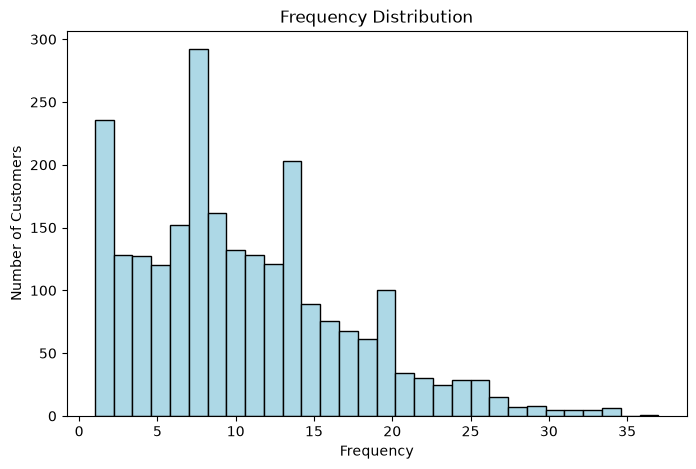

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["Frequency"], bins=30, color='lightblue', edgecolor='black')

plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.title("Frequency Distribution")

plt.show()

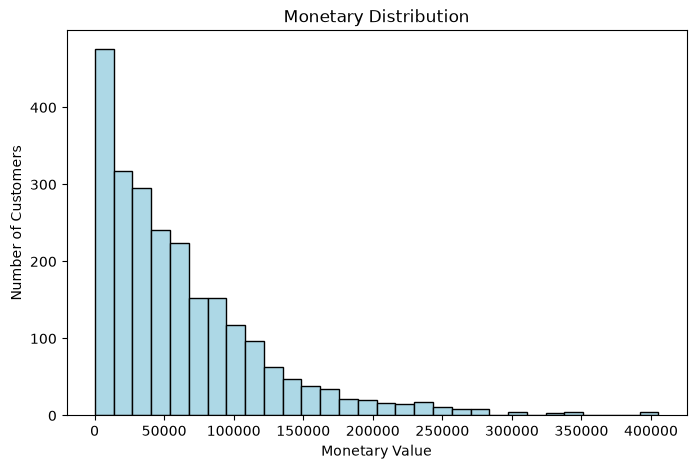

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["Monetary"], bins=30, color='lightblue', edgecolor='black')

plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")
plt.title("Monetary Distribution")

plt.show()

In [37]:
from sklearn.preprocessing import StandardScaler

X = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[ 0.38730628 -0.82093958 -0.76452029]
 [-0.48285938  2.0448515   1.70954522]
 [-0.22180968 -0.97177069 -0.84877743]
 ...
 [-0.39584281 -0.67010847 -0.72806061]
 [-0.22180968  0.5365404  -0.31157304]
 [-0.48285938  1.29069595  0.93026221]]


In [38]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

print(inertia)

[7181.999999999997, 4075.0668275711405, 2285.274886500135, 1572.0356056735895, 1236.028618779655, 988.0384978761351, 852.8203764965142, 769.3099893195704, 689.8687522926716, 624.0859233410844]


In [39]:
kl = KneeLocator(
    range(1, 11),
    inertia,
    curve="convex",
    direction="decreasing"
)

optimal_k = kl.elbow

print("Optimal K:", optimal_k)

Optimal K: 3


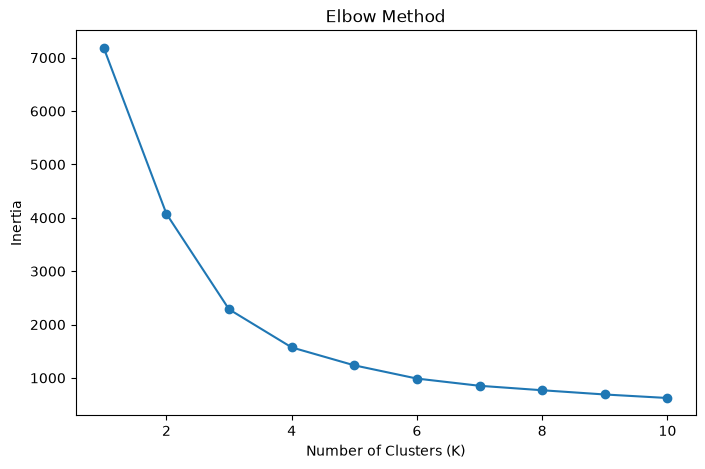

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [41]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print(rfm.head())

  CustomerID  Recency  Frequency   Monetary  Cluster
0     C00001       83          5   16795.33        2
1     C00002       13         24  167127.66        0
2     C00004       34          4   11675.59        2
3     C00005        2         18  135707.85        0
4     C00006      309          2   20151.03        1


In [42]:
print(rfm["Cluster"].value_counts().sort_index())

Cluster
0     656
1     227
2    1511
Name: count, dtype: int64


In [43]:
cluster_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          13.78      18.78  139434.02
1         267.40       2.03    8375.83
2          35.99       8.09   38418.72


In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", score)

Silhouette Score: 0.4977141453310471


In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(pca.explained_variance_ratio_)
print((pca.explained_variance_ratio_ * 100).round(2))

(2394, 2)
[0.7263816  0.22238761]
[72.64 22.24]


In [50]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

print(pca_df.head())

        PC1       PC2  Cluster
0 -1.170575 -0.190124        2
1  2.567767  0.803472        0
2 -1.026901 -0.788828        2
3  1.743697  0.251818        0
4 -2.766106  2.166153        1


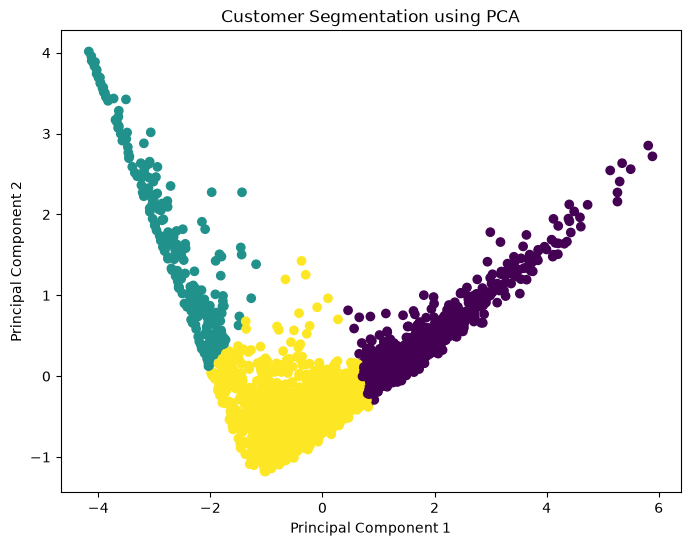

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using PCA")

plt.show()

In [53]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

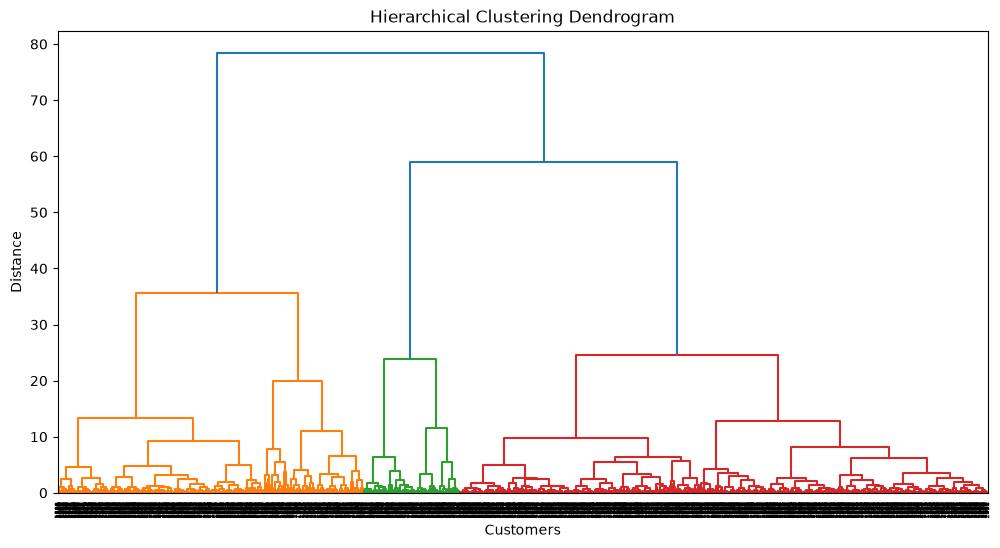

In [59]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.xlabel("Customers")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [60]:
optimal_k = 3

In [61]:
model = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

rfm["Hierarchical_Cluster"] = model.fit_predict(X_scaled)

In [62]:
score = silhouette_score(
    X_scaled,
    rfm["Hierarchical_Cluster"]
)

print("Hierarchical Silhouette Score:", score)

Hierarchical Silhouette Score: 0.47292663512696453


In [63]:
print(rfm["Hierarchical_Cluster"].value_counts().sort_index())

Hierarchical_Cluster
0     788
1    1359
2     247
Name: count, dtype: int64


In [64]:
hierarchical_profile = (
    rfm.groupby("Hierarchical_Cluster")[["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

print(hierarchical_profile)

                      Recency  Frequency   Monetary
Hierarchical_Cluster                               
0                       14.14      17.99  127022.57
1                       36.65       7.59   36325.69
2                      255.70       2.03    7936.49


In [70]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print(
    rfm["DBSCAN_Cluster"]
      .value_counts()
      .sort_index()
)

mask = rfm["DBSCAN_Cluster"] != -1

if rfm.loc[mask, "DBSCAN_Cluster"].nunique() >= 2:

    score = silhouette_score(
        X_scaled[mask],
        rfm.loc[mask, "DBSCAN_Cluster"]
    )

    print("DBSCAN Silhouette Score:", score)

else:
    print("Silhouette Score cannot be calculated.")

DBSCAN_Cluster
-1       4
 0    2390
Name: count, dtype: int64
Silhouette Score cannot be calculated.


In [71]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(
        f"eps={eps} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=0.2 | clusters=6 | noise=179
eps=0.3 | clusters=2 | noise=83
eps=0.4 | clusters=1 | noise=41
eps=0.5 | clusters=1 | noise=23
eps=0.6 | clusters=1 | noise=15
eps=0.7 | clusters=1 | noise=7


In [72]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

mask = rfm["DBSCAN_Cluster"] != -1

score = silhouette_score(
    X_scaled[mask],
    rfm.loc[mask, "DBSCAN_Cluster"]
)

print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.07798095648699783


In [73]:
print(rfm["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     179
 0    2161
 1      22
 2      18
 3       4
 4       5
 5       5
Name: count, dtype: int64


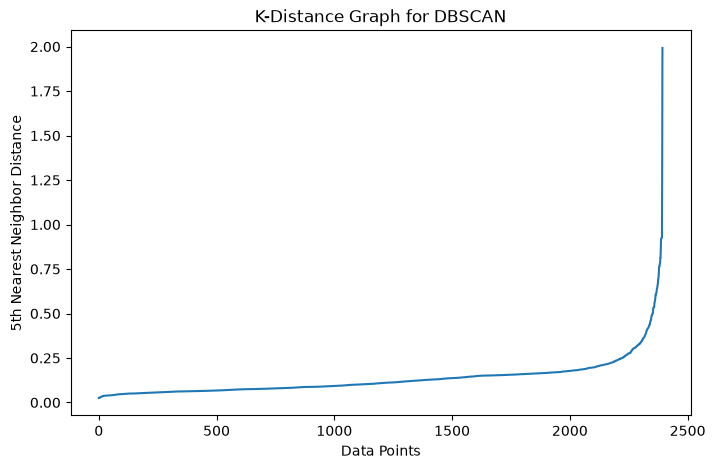

In [74]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = distances[:, 4]

distances = sorted(distances)
plt.figure(figsize=(8, 5))

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")

plt.show()

In [75]:
eps_values = [0.25, 0.27, 0.29, 0.30, 0.32, 0.34, 0.36]
min_samples_values = [4, 5, 6, 8]

for min_samples in min_samples_values:

    for eps in eps_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        if n_clusters >= 2:
            mask = labels != -1

            score = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )
        else:
            score = None

        print(
            f"eps={eps} | "
            f"min_samples={min_samples} | "
            f"clusters={n_clusters} | "
            f"noise={n_noise} | "
            f"silhouette={score}"
        )

eps=0.25 | min_samples=4 | clusters=4 | noise=99 | silhouette=-0.2307040591221181
eps=0.27 | min_samples=4 | clusters=2 | noise=88 | silhouette=0.5655058104993506
eps=0.29 | min_samples=4 | clusters=2 | noise=82 | silhouette=0.5645706985008176
eps=0.3 | min_samples=4 | clusters=3 | noise=75 | silhouette=-0.1123057074184724
eps=0.32 | min_samples=4 | clusters=4 | noise=57 | silhouette=-0.1158765415463563
eps=0.34 | min_samples=4 | clusters=2 | noise=47 | silhouette=0.5758062637184465
eps=0.36 | min_samples=4 | clusters=2 | noise=40 | silhouette=0.5747300085703433
eps=0.25 | min_samples=5 | clusters=2 | noise=114 | silhouette=0.37758105782419094
eps=0.27 | min_samples=5 | clusters=3 | noise=96 | silhouette=0.3801601961316593
eps=0.29 | min_samples=5 | clusters=2 | noise=88 | silhouette=0.5661430406380159
eps=0.3 | min_samples=5 | clusters=2 | noise=83 | silhouette=0.5654812621178369
eps=0.32 | min_samples=5 | clusters=2 | noise=72 | silhouette=0.5618229418754883
eps=0.34 | min_samples=5 

In [76]:
dbscan = DBSCAN(
    eps=0.34,
    min_samples=4
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

In [77]:
print(rfm["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1      47
 0    2343
 1       4
Name: count, dtype: int64


In [78]:
mask = rfm["DBSCAN_Cluster"] != -1

score = silhouette_score(
    X_scaled[mask],
    rfm.loc[mask, "DBSCAN_Cluster"]
)

print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.5758062637184465


In [79]:
dbscan_profile = (
    rfm.groupby("DBSCAN_Cluster")[["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

print(dbscan_profile)

                Recency  Frequency   Monetary
DBSCAN_Cluster                               
-1                84.96      15.74  184174.16
 0                51.25      10.31   60411.96
 1                 8.50      28.50  304827.96


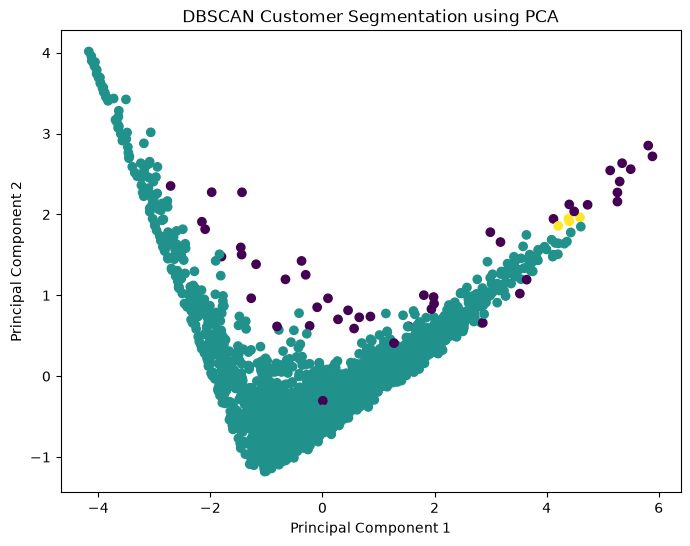

In [80]:
pca_df["DBSCAN_Cluster"] = rfm["DBSCAN_Cluster"].values

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["DBSCAN_Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segmentation using PCA")

plt.show()

In [81]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Clusters": [
        rfm["Cluster"].nunique(),
        rfm["Hierarchical_Cluster"].nunique(),
        rfm.loc[rfm["DBSCAN_Cluster"] != -1, "DBSCAN_Cluster"].nunique()
    ],
    "Noise Points": [
        0,
        0,
        (rfm["DBSCAN_Cluster"] == -1).sum()
    ],
    "Silhouette Score": [
        0.4977141453310471,
        0.47292663512696453,
        0.578062637184465
    ]
})

print(comparison)

      Algorithm  Clusters  Noise Points  Silhouette Score
0       K-Means         3             0          0.497714
1  Hierarchical         3             0          0.472927
2        DBSCAN         2            47          0.578063


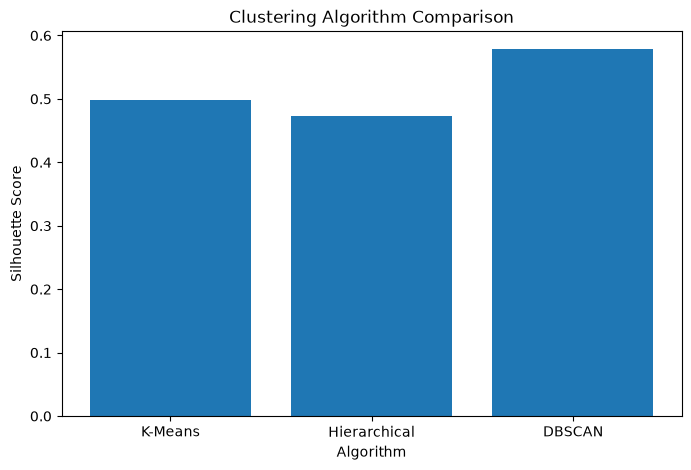

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Algorithm"],
    comparison["Silhouette Score"]
)

plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Clustering Algorithm Comparison")

plt.show()

In [83]:
print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          13.78      18.78  139434.02
1         267.40       2.03    8375.83
2          35.99       8.09   38418.72


In [84]:
segment_names = {
    0: "High-Value / Loyal",
    1: "Inactive / Low-Value",
    2: "Regular / Mid-Value"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

print(rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]].head())

  CustomerID  Recency  Frequency   Monetary  Cluster               Segment
0     C00001       83          5   16795.33        2   Regular / Mid-Value
1     C00002       13         24  167127.66        0    High-Value / Loyal
2     C00004       34          4   11675.59        2   Regular / Mid-Value
3     C00005        2         18  135707.85        0    High-Value / Loyal
4     C00006      309          2   20151.03        1  Inactive / Low-Value


In [85]:
segment_summary = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

print(segment_summary)

                      Recency  Frequency   Monetary
Segment                                            
High-Value / Loyal      13.78      18.78  139434.02
Inactive / Low-Value   267.40       2.03    8375.83
Regular / Mid-Value     35.99       8.09   38418.72


In [89]:
from sklearn.cluster import KMeans
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

In [90]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_model.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)","[[-0.

In [91]:
joblib.dump(
    scaler,
    model_dir / "scaler.joblib"
)

joblib.dump(
    kmeans_model,
    model_dir / "kmeans_model.joblib"
)

joblib.dump(
    segment_names,
    model_dir / "segment_names.joblib"
)

['..\\models\\segment_names.joblib']

In [92]:
print(list(model_dir.iterdir()))

[WindowsPath('../models/kmeans_model.joblib'), WindowsPath('../models/scaler.joblib'), WindowsPath('../models/segment_names.joblib')]


In [96]:
# Load the trained model and make predictions on new data
loaded_scaler = joblib.load(model_dir / "scaler.joblib")
loaded_model = joblib.load(model_dir / "kmeans_model.joblib")
loaded_names = joblib.load(model_dir / "segment_names.joblib")

# Example new data
test_customer = [[20, 18, 140000]]

# Scale the new data
test_scaled = loaded_scaler.transform(test_customer)

# Make a prediction
cluster = loaded_model.predict(test_scaled)[0]

# Map the cluster to a segment name
segment = loaded_names[cluster]

print("Cluster:", cluster)
print("Segment:", segment)

Cluster: 0
Segment: High-Value / Loyal


c:\Users\sanga\anaconda3\envs\cis\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
